**Name:** Ibrahim Khaled Al-Khamis

**Section:** 7MA01

**Course:**   ARTI 403 – Image Processing

---
# Lab 2:   Digital Image Fundamentals

### Step#1: Import the libraries


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage import data

### Step#2: Define Functions


In [3]:
def sample_image(image, factor):
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image

def quantize_image(image, levels):
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image

def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')
    plt.show()

### Step#3: Import the image and set the parameters

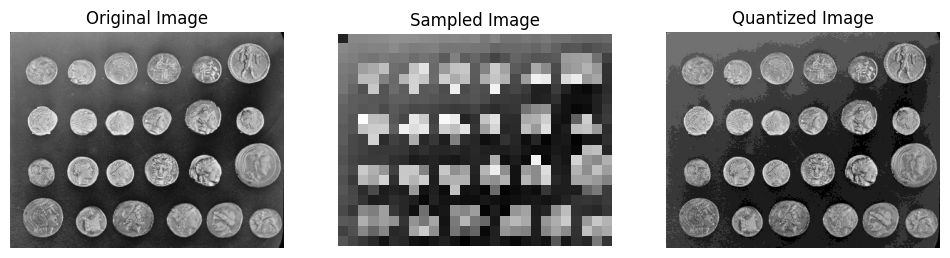

In [4]:
image_path = '../images/lena_gray_256.tif'
sampling_factor = 14
quantization_levels = 9

# Load image in grayscale
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:
    print(f"Error: Unable to load image at {image_path}")
else:
    # Sample and quantize
    sampled_image = sample_image(original_image, sampling_factor)
    quantized_image = quantize_image(original_image, quantization_levels)

    # Plot results
    plot_images(original_image, sampled_image, quantized_image)

### Task#1: Change the sampling and quantization parameters and observe the effects

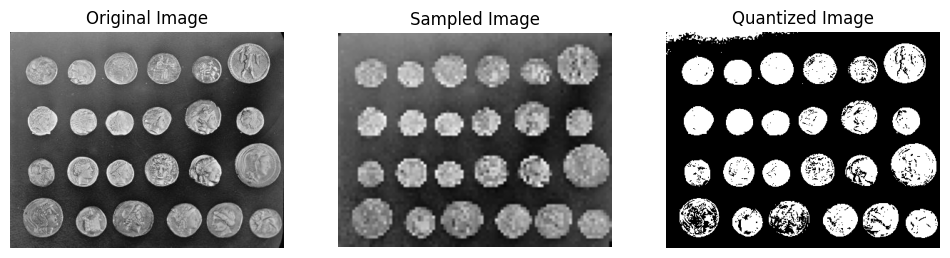

In [5]:
# Changed parameters for observation
new_sampling_factor = 4
new_quantization_levels = 2

new_sampled_image = sample_image(original_image, new_sampling_factor)
new_quantized_image = quantize_image(original_image, new_quantization_levels)

plot_images(original_image, new_sampled_image, new_quantized_image)

By decreasing the sampling factor to 4, the image retains higher spatial resolution compared to factor 14. However, drastically lowering the quantization levels to 2 creates severe false contouring, reducing the image to only black and white with no smooth gray transitions.

### Task#2: Read two images, convert them into arrays, and perform operations

In [6]:
img1_np = data.camera()
img2_np = data.coins()

img1 = Image.fromarray(img1_np)
img2 = Image.fromarray(img2_np)

resize = (400, 400)
img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

### 1. Subtract two images and display the result

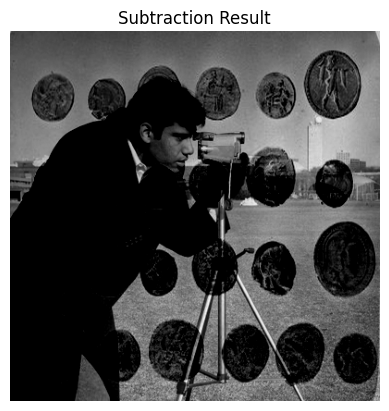

In [7]:
subtraction = cv2.subtract(im1arr, im2arr)

plt.imshow(subtraction, cmap='gray')
plt.title("Subtraction Result")
plt.axis('off')
plt.show()

### 2. Add one image with a constant value of 175 and display it

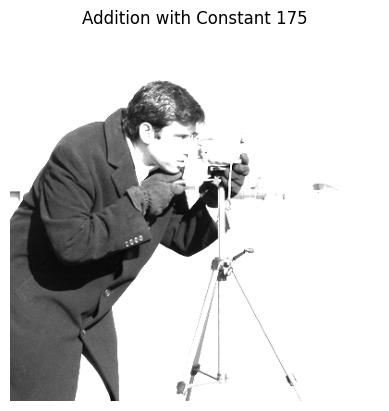

In [8]:
add_constant = cv2.add(im1arr, 175)

plt.imshow(add_constant, cmap='gray')
plt.title("Addition with Constant 175")
plt.axis('off')
plt.show()

### 3. Apply the set difference operation on two Gray-Scale images

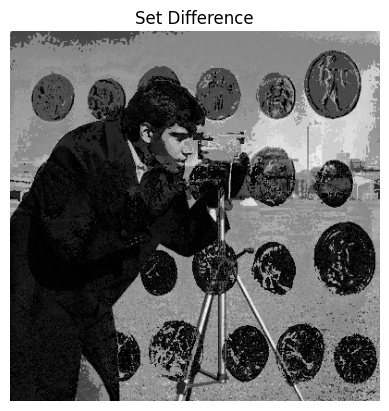

In [9]:
set_difference = cv2.bitwise_and(im1arr, cv2.bitwise_not(im2arr))

plt.imshow(set_difference, cmap='gray')
plt.title("Set Difference")
plt.axis('off')
plt.show()

### 4. Apply the symmetric difference operation on two Gray-Scale images

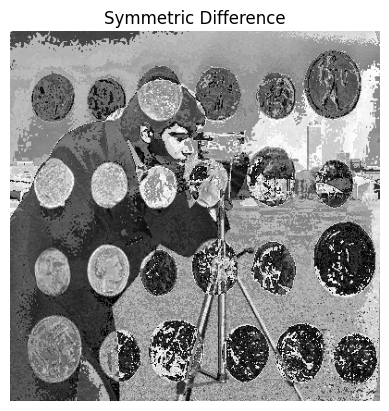

In [10]:
symmetric_difference = cv2.bitwise_xor(im1arr, im2arr)

plt.imshow(symmetric_difference, cmap='gray')
plt.title("Symmetric Difference")
plt.axis('off')
plt.show()

### 5. Apply Intersection operations on two Gray-Scale images

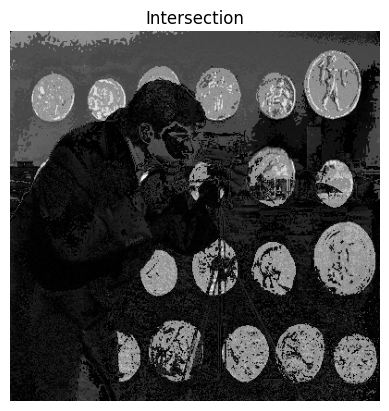

In [11]:
intersection = cv2.bitwise_and(im1arr, im2arr)

plt.imshow(intersection, cmap='gray')
plt.title("Intersection")
plt.axis('off')
plt.show()

---